In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

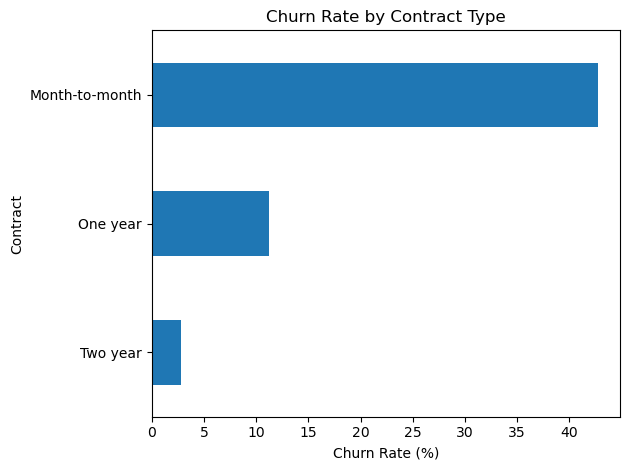


Average Tenure:
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


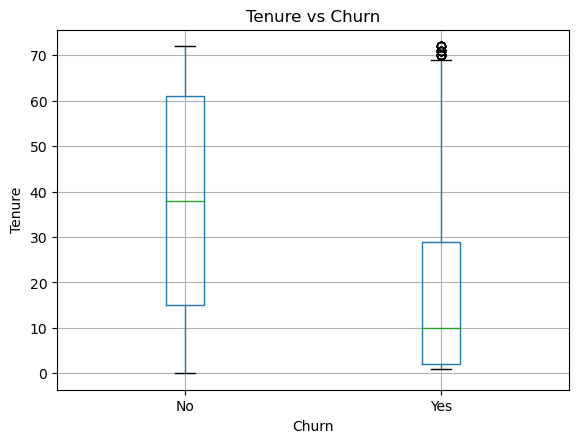


Monthly Charges Average:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


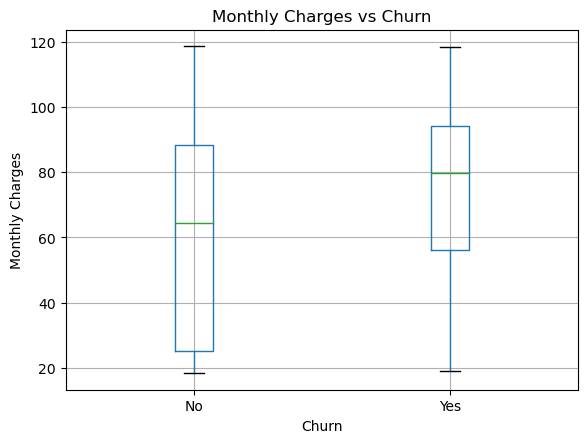


Payment Method vs Churn (%):
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


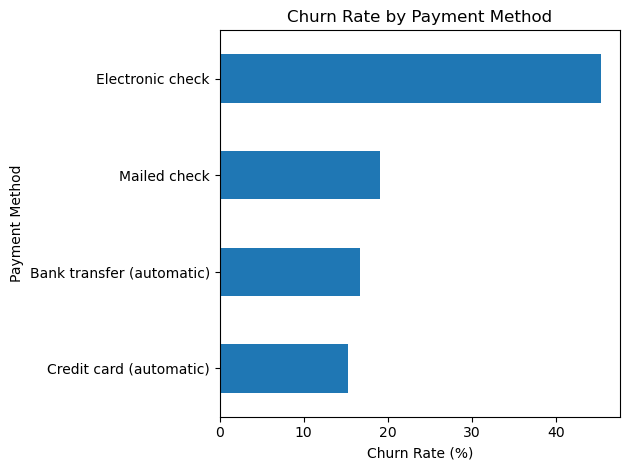


--- KEY INSIGHTS ---
- Highest churn is in 'Month-to-month' contracts.
- Customers who churn have lower average tenure (18.0) vs retained (37.6).
- Churned customers pay higher monthly charges (74.44) vs retained (61.27).
- Highest churn by payment method: Electronic check


In [7]:
## 1) DATASET

df = pd.read_csv("/home/cevo/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv" , sep=None, engine="python")
print("Shape:", df.shape)
print(df.head())

## 2) DATA CLEANİNG

# Convert TotalCharges column to numeric format, handling non-numeric values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill na values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Remove ID column
df.drop("customerID", axis=1, inplace=True)

## 3) CHURN RATE

churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].value_counts(normalize=True) * 100

print("\nChurn Count:")
print(churn_counts)

print("\nChurn Rate (%):")
print(churn_rate.round(2))


## 4) CONTRACT ANALYSIS

contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print("\nContract vs Churn (%):")
print(contract_churn.round(2))

contract_churn["Yes"].sort_values().plot(kind="barh")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Contract")
plt.tight_layout()
plt.show()

## 5) TENURE ANALYSIS

tenure_avg = df.groupby("Churn")["tenure"].mean()
print("\nAverage Tenure:")
print(tenure_avg)

df.boxplot(column="tenure", by="Churn")
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

## 6) MONTHLY CHARGES ANALYSIS

monthly_avg = df.groupby("Churn")["MonthlyCharges"].mean()
print("\nMonthly Charges Average:")
print(monthly_avg)

df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## 7) PAYMENT METHOD ANALYSIS

payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
print("\nPayment Method vs Churn (%):")
print(payment_churn.round(2))

payment_churn["Yes"].sort_values().plot(kind="barh")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

## 8) INSIGHTS

print("\n--- KEY INSIGHTS ---")

# Contract insight
worst_contract = contract_churn["Yes"].idxmax()
print(f"- Highest churn is in '{worst_contract}' contracts.")

# Tenure insight
print(f"- Customers who churn have lower average tenure ({tenure_avg['Yes']:.1f}) vs retained ({tenure_avg['No']:.1f}).")

# Monthly charges insight
print(f"- Churned customers pay higher monthly charges ({monthly_avg['Yes']:.2f}) vs retained ({monthly_avg['No']:.2f}).")

# Payment insight
worst_payment = payment_churn["Yes"].idxmax()
print(f"- Highest churn by payment method: {worst_payment}")


11
